In [1]:
from __future__ import annotations

import sys
import inspect
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd

import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
import torch
DEVICE = torch.device("cpu")

print(torch.device)                 # should print <class 'torch.device'>
print(isinstance(torch.device("cpu"), torch.device))

import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

<class 'torch.device'>
True


In [2]:
REPO_ROOT = Path(r"C:\Users\ROG\Documents\GitHub_T\Katabatic").resolve()
DATA_DIR  = REPO_ROOT / "raw_data"
OUT_DIR   = REPO_ROOT / "synthetic"

DATASETS = ["adult", "car", "shuttle", "nursery", "magic"]

SEED = 42
EPOCHS = 50
BATCH_SIZE = 512
LR = 1e-3

HIDDEN_DIM = 256
LATENT_DIM = 32
LAYER = 2          # adjust if your VAE expects different
GATE = 1           # 0/1
FLOW = 1           # 0/1 (turn on NF)
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""   # hide GPUs
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # optional, harmless

import torch

DEVICE = torch.device("cpu")

# Optional: prevent accidental .cuda() usage
torch.Tensor.cuda = lambda self, *args, **kwargs: self
torch.nn.Module.cuda = lambda self, *args, **kwargs: self

print("✅ CPU-only mode forced (no torch.device monkeypatch).")



✅ CPU-only mode forced (no torch.device monkeypatch).


In [3]:
# =========================
# Reproducibility
# =========================
def seed_everything(seed: int = 42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


In [4]:
# =========================
# Dynamic import (flow-VAE folder has "-")
# =========================
def load_flow_vae_module(repo_root: Path):
    import importlib.util

    candidates = [
        repo_root / r"katabatic\models\flow-VAE\dynamic_flow_vae.py",
        repo_root / r"katabatic\models\flow-VAE\static_flow_vae.py",
        repo_root / r"katabatic\models\flow-VAE\static_flow_conv_vae.py",
    ]
    last_err = None
    for p in candidates:
        if not p.exists():
            continue
        try:
            spec = importlib.util.spec_from_file_location(p.stem, str(p))
            m = importlib.util.module_from_spec(spec)
            spec.loader.exec_module(m)
            print(f"✅ Loaded flow-VAE module: {p}")
            return m, p
        except Exception as e:
            last_err = e
            print(f"⚠️ Failed to load {p.name}: {type(e).__name__}: {e}")
    raise ImportError("Could not load any flow-VAE module from katabatic/models/flow-VAE/.") from last_err


def pick_model_class(module):
    if hasattr(module, "VAE") and isinstance(getattr(module, "VAE"), type):
        cls = getattr(module, "VAE")
        print("✅ Using ModelClass = VAE")
        print("🧾 Signature:", "VAE" + str(inspect.signature(cls.__init__)))
        return cls
    raise ImportError("Could not find class VAE in the loaded module.")


In [5]:
# =========================
# Data helpers (robust)
# =========================
def strip_object_cols(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for c in df.columns:
        if df[c].dtype == "object":
            df[c] = df[c].astype(str).str.strip()
    return df


def detect_target_column(df: pd.DataFrame) -> str:
    common = ["label", "target", "class", "y", "income"]
    lower_map = {c.lower(): c for c in df.columns}
    for k in common:
        if k in lower_map:
            return lower_map[k]
    return df.columns[-1]


def build_dummy_encoding(X: pd.DataFrame) -> Tuple[pd.DataFrame, Dict[str, List[str]], List[str], List[str]]:
    """
    X_dummy: numeric-only design matrix
    dummy_groups: original_cat_col -> list of dummy columns
    num_cols, cat_cols: original feature lists
    """
    X = X.copy()

    num_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
    cat_cols = [c for c in X.columns if c not in num_cols]

    for c in cat_cols:
        X[c] = X[c].astype(str)

    X_dummy = pd.get_dummies(X, columns=cat_cols, drop_first=False)

    dummy_groups: Dict[str, List[str]] = {}
    for c in cat_cols:
        prefix = c + "_"
        dummy_groups[c] = [col for col in X_dummy.columns if col.startswith(prefix)]

    return X_dummy, dummy_groups, num_cols, cat_cols


def decode_from_dummies(
    X_dummy_synth: pd.DataFrame,
    dummy_groups: Dict[str, List[str]],
    num_cols: List[str],
    cat_cols: List[str],
    original_X: pd.DataFrame
) -> pd.DataFrame:
    out = pd.DataFrame(index=X_dummy_synth.index)

    # numeric columns: keep
    for c in num_cols:
        if c in X_dummy_synth.columns:
            out[c] = X_dummy_synth[c].astype(float)
        else:
            out[c] = np.random.choice(original_X[c].values, size=len(out), replace=True)

    # categorical: argmax per dummy block
    for c in cat_cols:
        cols = dummy_groups.get(c, [])
        if not cols:
            out[c] = np.random.choice(original_X[c].astype(str).values, size=len(out), replace=True)
            continue
        block = X_dummy_synth[cols].to_numpy()
        idx = block.argmax(axis=1)
        chosen = [cols[i] for i in idx]
        out[c] = [cc[len(c)+1:] for cc in chosen]

    return out[original_X.columns]

In [6]:
# =========================
# Model adapters (loss + sample)
# =========================
def instantiate_vae(ModelClass, dataset_name: str, in_dim: int):
    # Signature: VAE(dataset, layer, in_dim, hidden_dim, latent_dim, gate, flow, length)
    model = ModelClass(
        dataset_name,
        LAYER,
        in_dim,
        HIDDEN_DIM,
        LATENT_DIM,
        GATE,
        FLOW,
        in_dim  # length: safest default
    ).to(DEVICE)
    return model

def forward_unpack(model, xb):
    """
    Your VAE likely returns a tuple that includes (x_hat, mean, log_var, log_det)
    but exact ordering may vary. We'll detect by shapes.

    Returns: x_hat, mean, log_var, log_det
    """
    out = model(xb)

    if not isinstance(out, (tuple, list)):
        raise RuntimeError(f"Expected tuple/list from model(x), got {type(out)}")

    # Collect tensor-like items only (some implementations return extras)
    items = [t for t in out if torch.is_tensor(t)]

    if not items:
        raise RuntimeError("model(x) returned no tensors; cannot compute loss.")

    # x_hat: tensor with same shape as xb
    x_hat = None
    for t in items:
        if t.shape == xb.shape:
            x_hat = t
            break
    if x_hat is None:
        # fallback: first tensor might be recon
        x_hat = items[0]

    # mean/log_var: likely (batch, latent_dim)
    # pick two tensors with ndim==2 and second dim == LATENT_DIM if possible
    nd2 = [t for t in items if t.ndim == 2]
    mean, log_var = None, None
    if len(nd2) >= 2:
        # prefer ones matching latent dim
        cand = [t for t in nd2 if t.shape[1] == LATENT_DIM]
        if len(cand) >= 2:
            mean, log_var = cand[0], cand[1]
        else:
            mean, log_var = nd2[0], nd2[1]
    else:
        raise RuntimeError("Could not find mean/log_var tensors (ndim==2) in model output.")

    # log_det: often (batch,) or scalar
    log_det = None
    for t in items:
        if t.ndim == 1 and t.shape[0] == xb.shape[0]:
            log_det = t
            break
    if log_det is None:
        # If flow disabled or not returned, set 0
        log_det = torch.zeros(xb.shape[0], device=xb.device)

    return x_hat, mean, log_var, log_det


def compute_loss_katabatic(model, xb):
    """
    Correct Katabatic loss usage:
      loss = model.loss(x, x_hat, mean, log_var, log_det)
    """
    x_hat, mean, log_var, log_det = forward_unpack(model, xb)

    # Try the 5-arg form (matches your error context)
    try:
        loss = model.loss(xb, x_hat, mean, log_var, log_det)
        if torch.is_tensor(loss):
            return loss
        if isinstance(loss, dict) and "loss" in loss:
            return loss["loss"]
        # if returned tuple, assume first is loss
        if isinstance(loss, (tuple, list)) and len(loss) > 0 and torch.is_tensor(loss[0]):
            return loss[0]
        raise RuntimeError(f"Unexpected loss return type: {type(loss)}")
    except TypeError:
        # Some variants define loss(x_hat, mean, log_var, log_det) without x
        loss = model.loss(x_hat, mean, log_var, log_det)
        if torch.is_tensor(loss):
            return loss
        if isinstance(loss, dict) and "loss" in loss:
            return loss["loss"]
        if isinstance(loss, (tuple, list)) and len(loss) > 0 and torch.is_tensor(loss[0]):
            return loss[0]
        raise RuntimeError(f"Unexpected loss return type: {type(loss)}")




def forward_unpack(model, xb):
    """
    Supports:
      A) model(x) -> (x_hat, mean, log_var, log_det, ...)
      B) model(x) -> x_hat  AND model stores mean/log_var/log_det as attributes
      C) model(x) -> x_hat  AND model has encode/encoder that returns mean/log_var
    """
    out = model(xb)

    # ---------- Case A: tuple/list ----------
    if isinstance(out, (tuple, list)):
        items = [t for t in out if torch.is_tensor(t)]
        if not items:
            raise RuntimeError("model(x) returned tuple/list but no tensors inside.")

        # x_hat
        x_hat = next((t for t in items if t.shape == xb.shape), items[0])

        # mean/log_var
        nd2 = [t for t in items if t.ndim == 2]
        if len(nd2) >= 2:
            mean, log_var = nd2[0], nd2[1]
        else:
            raise RuntimeError("Tuple/list output does not contain 2D mean/log_var tensors.")

        # log_det
        log_det = next((t for t in items if t.ndim == 1 and t.shape[0] == xb.shape[0]), None)
        if log_det is None:
            log_det = torch.zeros(xb.shape[0], device=xb.device)

        return x_hat, mean, log_var, log_det

    # ---------- Case B/C: tensor only ----------
    if torch.is_tensor(out):
        x_hat = out

        # 1) Try grabbing attributes set during forward
        def get_attr(*names):
            for n in names:
                if hasattr(model, n):
                    v = getattr(model, n)
                    if torch.is_tensor(v):
                        return v
            return None

        mean   = get_attr("mean", "mu", "z_mean")
        logvar = get_attr("log_var", "logvar", "z_log_var", "z_logvar")
        logdet = get_attr("log_det", "logdet")

        # 2) If mean/logvar not stored, try encode/encoder methods
        if mean is None or logvar is None:
            if hasattr(model, "encode") and callable(model.encode):
                enc = model.encode(xb)
                if isinstance(enc, (tuple, list)) and len(enc) >= 2:
                    mean, logvar = enc[0], enc[1]
            elif hasattr(model, "encoder") and callable(getattr(model, "encoder")):
                enc = model.encoder(xb)
                if isinstance(enc, (tuple, list)) and len(enc) >= 2:
                    mean, logvar = enc[0], enc[1]

        if mean is None or logvar is None:
            raise RuntimeError(
                "model(x) returned only x_hat, but mean/log_var were not found in model attributes "
                "and no encode/encoder method returned them."
            )

        if logdet is None:
            logdet = torch.zeros(xb.shape[0], device=xb.device)

        return x_hat, mean, logvar, logdet

    raise RuntimeError(f"Unsupported model(x) output type: {type(out)}")


def compute_loss_katabatic(model, xb):
    x_hat, mean, log_var, log_det = forward_unpack(model, xb)

    # Call katabatic loss in the correct format
    try:
        out = model.loss(xb, x_hat, mean, log_var, log_det)
    except TypeError:
        # some variants omit x
        out = model.loss(x_hat, mean, log_var, log_det)

    # Normalize "out" to a tensor loss
    if isinstance(out, dict):
        loss = out.get("loss", None)
        if loss is None:
            # sometimes keys are like 'total', 'elbo'
            for k in ["total", "elbo", "loss_total"]:
                if k in out:
                    loss = out[k]
                    break
        if loss is None:
            raise RuntimeError(f"loss dict keys={list(out.keys())} but no usable loss key found.")
    elif isinstance(out, (tuple, list)):
        # most common: (loss, recon, kl, ...)
        loss = out[0]
    else:
        loss = out

    if not torch.is_tensor(loss):
        raise RuntimeError(f"model.loss returned non-tensor: {type(loss)}")

    # ✅ ensure scalar
    if loss.ndim != 0:
        loss = loss.mean()

    return loss



In [7]:
def sample_generic(model, n_samples: int, in_dim: int):
    """
    Tries common Katabatic APIs:
      - model.sample(n)
      - model.generate(n)
      - model.sampling(n)
      - model.inference(n)
    If none exist, fall back to decoding random z if decode is available.
    """
    model.eval()
    with torch.no_grad():
        # 1) direct sampling methods
        for fn_name in ["sample", "generate", "sampling", "inference"]:
            if hasattr(model, fn_name) and callable(getattr(model, fn_name)):
                xs = getattr(model, fn_name)(n_samples)
                if isinstance(xs, (tuple, list)):
                    xs = xs[0]
                if torch.is_tensor(xs):
                    return xs.detach().cpu().numpy()
                return np.asarray(xs, dtype=np.float32)

        # 2) decode(random z) fallback
        # Try to infer latent dim from model attribute or config
        z_dim = None
        for attr in ["latent_dim", "z_dim", "latent_size"]:
            if hasattr(model, attr):
                try:
                    z_dim = int(getattr(model, attr))
                    break
                except Exception:
                    pass

        # if not present, assume LATENT_DIM global (common in your script)
        if z_dim is None:
            z_dim = LATENT_DIM  # uses your config constant

        if hasattr(model, "decode") and callable(getattr(model, "decode")):
            z = torch.randn(n_samples, z_dim, device=DEVICE)
            xs = model.decode(z)
            if isinstance(xs, (tuple, list)):
                xs = xs[0]
            if torch.is_tensor(xs):
                return xs.detach().cpu().numpy()
            return np.asarray(xs, dtype=np.float32)

    raise AttributeError(
        "No sampling method found. Tried: sample/generate/sampling/inference, and decode(z)."
    )


In [8]:
# =========================
# Train + generate one dataset
# =========================
def run_one(dataset_name: str, ModelClass):
    csv_path = DATA_DIR / f"{dataset_name}.csv"
    if not csv_path.exists():
        print(f"❌ Missing: {csv_path}")
        return

    df = pd.read_csv(csv_path)
    df = strip_object_cols(df)

    y_col = detect_target_column(df)
    X_raw = df.drop(columns=[y_col]).copy()
    y_raw = df[y_col].copy()

    # dummy encode (all numeric)
    X_dummy, dummy_groups, num_cols, cat_cols = build_dummy_encoding(X_raw)

    # scale numeric original columns (if present in dummy matrix)
    scaler_stats = {}
    for c in num_cols:
        if c in X_dummy.columns:
            mu = float(X_dummy[c].mean())
            sd = float(X_dummy[c].std())
            if sd < 1e-8:
                sd = 1.0
            X_dummy[c] = (X_dummy[c] - mu) / sd
            scaler_stats[c] = (mu, sd)

    X_train = torch.tensor(X_dummy.to_numpy(dtype=np.float32), dtype=torch.float32)
    in_dim = X_train.shape[1]

    model = instantiate_vae(ModelClass, dataset_name, in_dim)

    loader = DataLoader(TensorDataset(X_train), batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    opt = torch.optim.Adam(model.parameters(), lr=LR)

    model.train()
    for epoch in range(1, EPOCHS + 1):
        total = 0.0
        for (xb,) in loader:
            xb = xb.to(DEVICE)
            opt.zero_grad()
            loss = compute_loss_katabatic(model, xb)
            loss.backward()
            opt.step()
            total += float(loss.item())
        if epoch == 1 or epoch % 10 == 0:
            print(f"[{dataset_name}] Epoch {epoch:03d} | loss={total/len(loader):.4f}")

    # sample in dummy space
    X_synth = sample_generic(model, n_samples=len(X_dummy), in_dim=in_dim)
    X_synth = np.asarray(X_synth, dtype=np.float32)

    X_synth_df = pd.DataFrame(X_synth, columns=X_dummy.columns)

    # unscale numeric cols back
    for c, (mu, sd) in scaler_stats.items():
        if c in X_synth_df.columns:
            X_synth_df[c] = X_synth_df[c] * sd + mu

    # decode dummies -> original schema
    X_decoded = decode_from_dummies(X_synth_df, dummy_groups, num_cols, cat_cols, X_raw)

    # add target back by sampling empirical distribution
    synth_full = X_decoded.copy()
    synth_full[y_col] = np.random.choice(y_raw.values, size=len(synth_full), replace=True)

    out_path = OUT_DIR / dataset_name / "vae_nf"
    out_path.mkdir(parents=True, exist_ok=True)
    out_file = out_path / "x_synth.csv"
    synth_full.to_csv(out_file, index=False)
    print(f"✅ Saved synthetic CSV: {out_file}")

In [9]:
# =========================
# Main
# =========================
def main():
    seed_everything(SEED)

    if str(REPO_ROOT) not in sys.path:
        sys.path.insert(0, str(REPO_ROOT))

    module, _ = load_flow_vae_module(REPO_ROOT)
    ModelClass = pick_model_class(module)

    for ds in DATASETS:
        print("\n" + "=" * 80)
        print(f"🚀 Running dataset: {ds}")
        try:
            run_one(ds, ModelClass)
        except Exception as e:
            print(f"❌ Failed on {ds}: {type(e).__name__}: {e}")

    print("\n✅ Done.")


if __name__ == "__main__":
    main()

✅ Loaded flow-VAE module: C:\Users\ROG\Documents\GitHub_T\Katabatic\katabatic\models\flow-VAE\dynamic_flow_vae.py
✅ Using ModelClass = VAE
🧾 Signature: VAE(self, dataset, layer, in_dim, hidden_dim, latent_dim, gate, flow, length)

🚀 Running dataset: adult


C:\Users\ROG\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([512, 108])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


[adult] Epoch 001 | loss=12597.4335
[adult] Epoch 010 | loss=6964.4971
[adult] Epoch 020 | loss=6599.4725
[adult] Epoch 030 | loss=6470.3131
[adult] Epoch 040 | loss=6385.8411
[adult] Epoch 050 | loss=6388.1978
✅ Saved synthetic CSV: C:\Users\ROG\Documents\GitHub_T\Katabatic\synthetic\adult\vae_nf\x_synth.csv

🚀 Running dataset: car
[car] Epoch 001 | loss=662.6817


C:\Users\ROG\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([512, 21])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


[car] Epoch 010 | loss=345.8471
[car] Epoch 020 | loss=338.1436
[car] Epoch 030 | loss=337.3899
[car] Epoch 040 | loss=337.4500
[car] Epoch 050 | loss=337.7172
✅ Saved synthetic CSV: C:\Users\ROG\Documents\GitHub_T\Katabatic\synthetic\car\vae_nf\x_synth.csv

🚀 Running dataset: shuttle


...

[shuttle] Epoch 001 | loss=446.1956
[shuttle] Epoch 010 | loss=276.1184
[shuttle] Epoch 020 | loss=262.9451
[shuttle] Epoch 030 | loss=257.4703
[shuttle] Epoch 040 | loss=255.1768
[shuttle] Epoch 050 | loss=253.2203
✅ Saved synthetic CSV: C:\Users\ROG\Documents\GitHub_T\Katabatic\synthetic\shuttle\vae_nf\x_synth.csv

🚀 Running dataset: nursery


C:\Users\ROG\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([512, 27])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


[nursery] Epoch 001 | loss=980.5727
[nursery] Epoch 010 | loss=732.8721
[nursery] Epoch 020 | loss=731.0882
[nursery] Epoch 030 | loss=729.6726
[nursery] Epoch 040 | loss=729.2592
[nursery] Epoch 050 | loss=728.6098
✅ Saved synthetic CSV: C:\Users\ROG\Documents\GitHub_T\Katabatic\synthetic\nursery\vae_nf\x_synth.csv

🚀 Running dataset: magic


C:\Users\ROG\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([512, 10])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


[magic] Epoch 001 | loss=783.7303
[magic] Epoch 010 | loss=391.6407
[magic] Epoch 020 | loss=365.1973
[magic] Epoch 030 | loss=351.0967
[magic] Epoch 040 | loss=346.9241
[magic] Epoch 050 | loss=341.5105
✅ Saved synthetic CSV: C:\Users\ROG\Documents\GitHub_T\Katabatic\synthetic\magic\vae_nf\x_synth.csv

✅ Done.


In [10]:
from sklearn.model_selection import train_test_split

def split_real_data(df):
    y_col = detect_target_column(df)
    X = df.drop(columns=[y_col])
    y = df[y_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.3,
        random_state=42,
        stratify=y if y.nunique() < len(y) else None
    )
    return X_train, X_test, y_train, y_test


In [11]:
def align_dummy_columns(X_ref, X_to_align):
    """Ensure X_to_align has same columns as X_ref"""
    X_to_align = X_to_align.copy()
    for c in X_ref.columns:
        if c not in X_to_align.columns:
            X_to_align[c] = 0
    return X_to_align[X_ref.columns]


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

def evaluate_tstr(
    X_synth, y_synth,
    X_test, y_test
):
    clf = LogisticRegression(
        max_iter=1000,
        n_jobs=1
    )
    clf.fit(X_synth, y_synth)

    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average="weighted")

    return acc, f1


In [13]:
results = []

for ds in ["adult", "car", "shuttle", "nursery", "magic"]:
    print(f"\n📊 Evaluating {ds}")

    # ---- Load real data ----
    df = pd.read_csv(DATA_DIR / f"{ds}.csv")
    df = strip_object_cols(df)
    y_col = detect_target_column(df)

    X_train_real, X_test_real, y_train_real, y_test_real = split_real_data(df)

    # ---- Dummy encode REAL train/test ----
    X_train_dummy, dummy_groups, num_cols, cat_cols = build_dummy_encoding(X_train_real)
    X_test_dummy = pd.get_dummies(X_test_real)

    X_test_dummy = align_dummy_columns(X_train_dummy, X_test_dummy)

    # ---- Load SYNTHETIC data ----
    synth_path = OUT_DIR / ds / "vae_nf" / "x_synth.csv"
    synth_df = pd.read_csv(synth_path)
    synth_df = strip_object_cols(synth_df)

    X_synth = synth_df.drop(columns=[y_col])
    y_synth = synth_df[y_col]

    X_synth_dummy = pd.get_dummies(X_synth)
    X_synth_dummy = align_dummy_columns(X_train_dummy, X_synth_dummy)

    # ---- Evaluate ----
    acc, f1 = evaluate_tstr(
        X_synth_dummy, y_synth,
        X_test_dummy, y_test_real
    )

    results.append({
        "dataset": ds,
        "accuracy": round(acc, 4),
        "f1_score": round(f1, 4)
    })



📊 Evaluating adult


C:\Users\ROG\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



📊 Evaluating car

📊 Evaluating shuttle


C:\Users\ROG\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
C:\Users\ROG\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
C:\Users\ROG\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.htm


📊 Evaluating nursery

📊 Evaluating magic


C:\Users\ROG\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [14]:
results_df = pd.DataFrame(results)
results_df


,dataset,accuracy,f1_score
0,adult,0.7592,0.6553
1,car,0.6994,0.5757
2,shuttle,0.7860,0.6918
3,nursery,0.3861,0.3303
4,magic,0.6484,0.5101


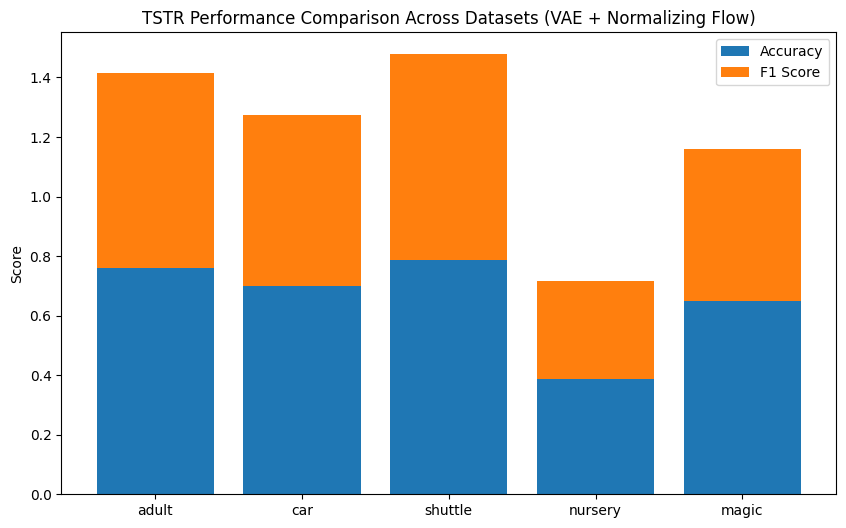

In [15]:
import matplotlib.pyplot as plt

# Data from the user's results
datasets = ["adult", "car", "shuttle", "nursery", "magic"]
accuracy = [0.7592, 0.6994, 0.7860, 0.3861, 0.6484]
f1_score = [0.6553, 0.5757, 0.6918, 0.3303, 0.5101]

# Create bar chart
plt.figure(figsize=(10, 6))

x = range(len(datasets))
plt.bar(x, accuracy, label="Accuracy")
plt.bar(x, f1_score, bottom=accuracy, label="F1 Score")

plt.xticks(x, datasets)
plt.ylabel("Score")
plt.title("TSTR Performance Comparison Across Datasets (VAE + Normalizing Flow)")
plt.legend()

plt.show()
